
Avec NumPy — empiler plusieurs tableaux

## vstack (vertical stack) empile les lignes les unes sous les autres — utile quand les fichiers ont les mêmes colonnes (mêmes modules) mais des étudiants différents

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


df_ia = pd.read_csv('data/notes_filiere_ia.csv')
df_reseaux = pd.read_csv('data/notes_filiere_reseaux.csv')

df_toutes_filieres = pd.concat([df_ia, df_reseaux], ignore_index=True)

df_toutes_filieres.shape

(100, 6)

In [15]:
df_ia.isnull()

,id_etudiant,filiere,Machine_Learning,Fouille_de_donnees,Bases_de_donnees,Statistiques
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,False,False


In [14]:
df_ia.shape

(60, 6)

In [ ]:
df_toutes_filieres.info

<bound method DataFrame.info of    id_etudiant  filiere  Machine_Learning  Fouille_de_donnees  \
0        IA001       IA                11                  11   
1        IA002       IA                 8                   6   
2        IA003       IA                17                   8   
3        IA004       IA                19                  13   
4        IA005       IA                15                  16   
..         ...      ...               ...                 ...   
95       RS036  Reseaux                 5                  15   
96       RS037  Reseaux                12                  10   
97       RS038  Reseaux                 5                  17   
98       RS039  Reseaux                15                   7   
99       RS040  Reseaux                 5                   8   

    Bases_de_donnees  Statistiques  
0                 14            11  
1                 13            19  
2                 16            18  
3                 16            11  
4 

Detection des  elements abscents

In [12]:
df_toutes_filieres.isnull()

,id_etudiant,filiere,Machine_Learning,Fouille_de_donnees,Bases_de_donnees,Statistiques
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
95,False,False,False,False,False,False
96,False,False,False,False,False,False
97,False,False,False,False,False,False
98,False,False,False,False,False,False


In [13]:
df_toutes_filieres.head

<bound method NDFrame.head of    id_etudiant  filiere  Machine_Learning  Fouille_de_donnees  \
0        IA001       IA                11                  11   
1        IA002       IA                 8                   6   
2        IA003       IA                17                   8   
3        IA004       IA                19                  13   
4        IA005       IA                15                  16   
..         ...      ...               ...                 ...   
95       RS036  Reseaux                 5                  15   
96       RS037  Reseaux                12                  10   
97       RS038  Reseaux                 5                  17   
98       RS039  Reseaux                15                   7   
99       RS040  Reseaux                 5                   8   

    Bases_de_donnees  Statistiques  
0                 14            11  
1                 13            19  
2                 16            18  
3                 16            11  
4   

Fusionner avec merge

In [20]:
presence = pd.read_csv('data/presence.csv')

df_complet = pd.merge(df_toutes_filieres, presence, on='id_etudiant', how='left')

df_complet.shape

(100, 7)

In [21]:
df_complet.head()

,id_etudiant,filiere,Machine_Learning,Fouille_de_donnees,Bases_de_donnees,Statistiques,taux_presence
0,IA001,IA,11,11,14,11,92
1,IA002,IA,8,6,13,19,73
2,IA003,IA,17,8,16,18,80
3,IA004,IA,19,13,16,11,79
4,IA005,IA,15,16,16,15,67


Moyenne par filière

In [22]:
moyennes_par_filiere = df_complet.groupby('filiere')[['Machine_Learning', 'Fouille_de_donnees', 'Bases_de_donnees', 'Statistiques']].mean()

moyennes_par_filiere

,Machine_Learning,Fouille_de_donnees,Bases_de_donnees,Statistiques
filiere,,,,
IA,12.450,12.566667,11.833333,13.516667
Reseaux,11.025,10.850000,11.325000,10.400000


Moyenne par eleve

In [23]:
colonnes_notes = ['Machine_Learning', 'Fouille_de_donnees', 'Bases_de_donnees', 'Statistiques']

df_complet['moyenne_generale'] = df_complet[colonnes_notes].mean(axis=1)

df_complet[['id_etudiant', 'filiere', 'moyenne_generale']].head()

,id_etudiant,filiere,moyenne_generale
0,IA001,IA,11.75
1,IA002,IA,11.50
2,IA003,IA,14.75
3,IA004,IA,14.75
4,IA005,IA,15.50


moyenne par matière (par colonne)

In [24]:
moyenne_par_matiere = df_complet[colonnes_notes].mean(axis=0)

moyenne_par_matiere

Machine_Learning      11.88
Fouille_de_donnees    11.88
Bases_de_donnees      11.63
Statistiques          12.27
dtype: float64

colonnes_notes = ['Machine_Learning', 'Fouille_de_donnees', 'Bases_de_donnees', 'Statistiques']

# 1. Moyenne par etudiant (axis=1 -> les colonnes disparaissent, resultat par ligne)
df_complet['moyenne_generale'] = df_complet[colonnes_notes].mean(axis=1)

print("=== Moyenne par etudiant (5 premiers) ===")
print(df_complet[['id_etudiant', 'filiere', 'moyenne_generale']].head())

print()

# 2. Moyenne par matiere (axis=0 -> les lignes disparaissent, resultat par colonne)
moyenne_par_matiere = df_complet[colonnes_notes].mean(axis=0)

print("=== Moyenne par matiere ===")
print(moyenne_par_matiere)

In [25]:
colonnes_notes = ['Machine_Learning', 'Fouille_de_donnees', 'Bases_de_donnees', 'Statistiques']

# 1. Moyenne par etudiant (axis=1 -> les colonnes disparaissent, resultat par ligne)
df_complet['moyenne_generale'] = df_complet[colonnes_notes].mean(axis=1)

print("=== Moyenne par etudiant (5 premiers) ===")
print(df_complet[['id_etudiant', 'filiere', 'moyenne_generale']].head())

print()

# 2. Moyenne par matiere (axis=0 -> les lignes disparaissent, resultat par colonne)
moyenne_par_matiere = df_complet[colonnes_notes].mean(axis=0)

print("=== Moyenne par matiere ===")
print(moyenne_par_matiere)

=== Moyenne par etudiant (5 premiers) ===
  id_etudiant filiere  moyenne_generale
0       IA001      IA             11.75
1       IA002      IA             11.50
2       IA003      IA             14.75
3       IA004      IA             14.75
4       IA005      IA             15.50

=== Moyenne par matiere ===
Machine_Learning      11.88
Fouille_de_donnees    11.88
Bases_de_donnees      11.63
Statistiques          12.27
dtype: float64


moyenne par matière (bar chart avec valeurs affichées) avec matpotlib

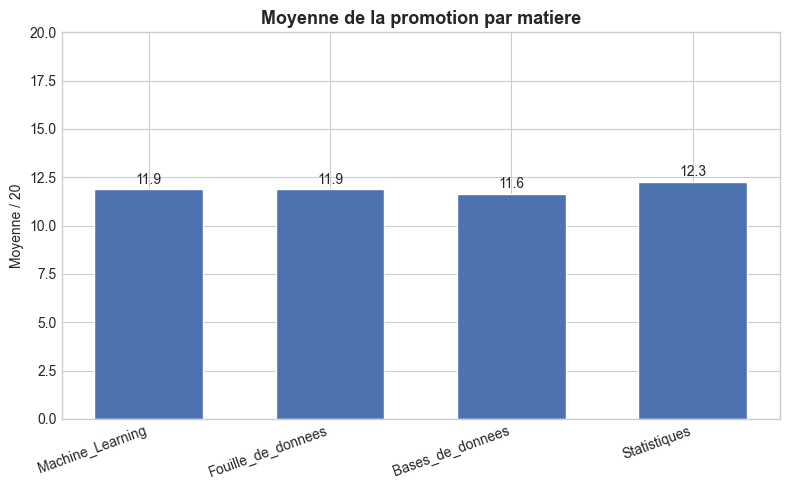

In [26]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(moyenne_par_matiere.index, moyenne_par_matiere.values,
              color='#4C72B0', edgecolor='white', width=0.6)

ax.set_title('Moyenne de la promotion par matiere', fontsize=13, fontweight='bold')
ax.set_ylabel('Moyenne / 20')
ax.set_ylim(0, 20)
ax.set_xticks(range(len(moyenne_par_matiere.index)))
ax.set_xticklabels(moyenne_par_matiere.index, rotation=20, ha='right')

# Afficher la valeur au-dessus de chaque barre
for bar in bars:
    hauteur = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, hauteur + 0.3, f'{hauteur:.1f}',
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Interprétation

### Moyenne par matière

Ce graphique permet d'identifier les matières où la promotion rencontre
le plus de difficultés.

Une moyenne faible peut indiquer :
- une difficulté conceptuelle du module ;
- un besoin de renforcement pédagogique ;
- un problème dans la méthode d'apprentissage.


### Moyenne par étudiant

L'analyse individuelle permet :

- d'identifier les meilleurs étudiants ;
- de détecter rapidement les étudiants en difficulté ;
- de mettre en place des actions d'accompagnement.


### Rappel Pandas

| Question | Axe utilisé | Résultat |
|---|---|---|
| Moyenne de chaque étudiant | axis=1 | une valeur par ligne |
| Moyenne de chaque matière | axis=0 | une valeur par colonne |

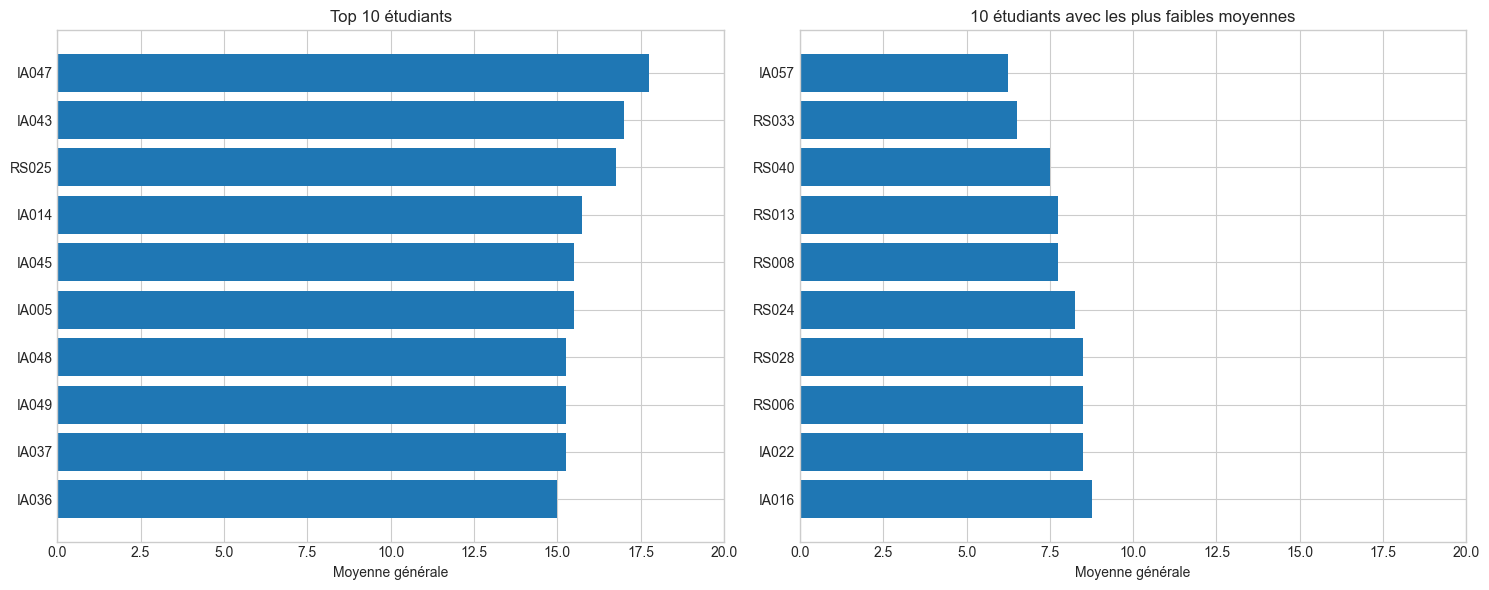

In [29]:
classement = (
    df_complet[
        [
            'id_etudiant',
            'filiere',
            'moyenne_generale'
        ]
    ]
    .sort_values(
        by="moyenne_generale",
        ascending=False
    )
)


top10 = classement.head(10)

bottom10 = classement.tail(10)



fig, axes = plt.subplots(
    1,
    2,
    figsize=(15,6)
)



# TOP 10

axes[0].barh(
    top10['id_etudiant'][::-1],
    top10['moyenne_generale'][::-1]
)

axes[0].set_title(
    "Top 10 étudiants"
)

axes[0].set_xlabel(
    "Moyenne générale"
)

axes[0].set_xlim(0,20)



# Difficultés

axes[1].barh(
    bottom10['id_etudiant'],
    bottom10['moyenne_generale']
)


axes[1].set_title(
    "10 étudiants avec les plus faibles moyennes"
)

axes[1].set_xlabel(
    "Moyenne générale"
)

axes[1].set_xlim(0,20)



plt.tight_layout()

plt.show()